In [1]:
import pandas as pd

df = pd.read_csv("/workspaces/KARMA-/data/raw/beijing_pm2/PRSA_data_2010.1.1-2014.12.31.csv")

# combine timestamp
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
df = df.set_index("datetime").sort_index()

df = df.drop(columns=["No", "year","month","day","hour"])

In [2]:
df.describe()

,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [3]:
df.isna().mean().sort_values(ascending=False)

pm2.5    0.047166
DEWP     0.000000
TEMP     0.000000
PRES     0.000000
cbwd     0.000000
Iws      0.000000
Is       0.000000
Ir       0.000000
dtype: float64

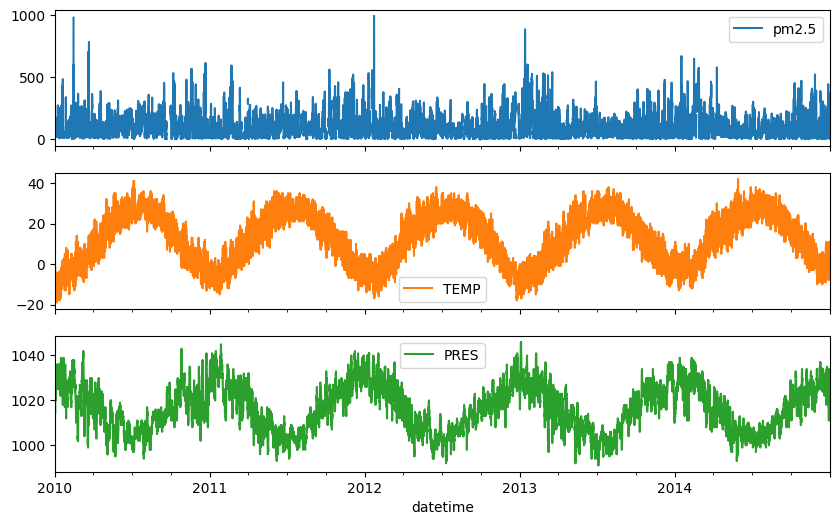

In [4]:
import matplotlib.pyplot as plt

df[["pm2.5", "TEMP", "PRES"]].plot(subplots=True, figsize=(10,6))
plt.show()

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

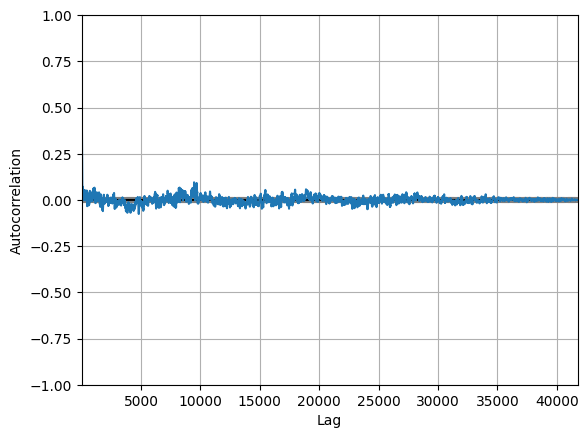

In [6]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df["pm2.5"].dropna())

In [7]:
df = df.interpolate(method="time")
df = df.fillna(method="bfill")

/tmp/ipykernel_4032/4004571104.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="time")
/tmp/ipykernel_4032/4004571104.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill")


In [8]:
df = df.dropna()

In [9]:
df = pd.get_dummies(df, columns=["cbwd"])

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    index=df.index,
    columns=df.columns
)

In [11]:
cols = ["pm2.5", "TEMP", "PRES", "DEWP", "Iws"]
df_scaled = df_scaled[cols]

In [12]:
def make_windows(X, W):
    X = X.values
    T, D = X.shape

    windows = []
    targets = []

    for t in range(W, T):
        windows.append(X[t-W:t])
        targets.append(X[t])

    return windows, targets

W = 10
windows, targets = make_windows(df_scaled, W)